# Category 3 : Prescriptive Analysis Questions

In [1]:
# Install Seaborn if needed.

!pip install pandas numpy matplotlib seaborn plotly
#Install Advanced Visualisation Libraries
!pip install bokeh altair holoviews hvplot
!pip install networkx squarify wordcloud
!pip install scipy statsmodels scikit-learn
!pip install streamlit
!pip install dash dash-bootstrap-components
!pip install panel


In [3]:
#Importing all the Necessary Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots




# Advanced Visualisation
import networkx as nx
import squarify
from wordcloud import WordCloud


# Dashboarding
import streamlit as st
import dash
import panel as pn

<p style="font-family: Cambria; font-size: 20px;"><b>Read the Datasets</b></p>

In [5]:
# Define the main project folder
project_folder = Path(
    r'C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure'
)

# Define the folder containing the original datasets
raw_data_folder = project_folder / "raw_data"

# Define the folder for cleaned datasets and reports
output_folder = project_folder / "cleaned_data"

# Create the output folder if it does not already exist
output_folder.mkdir(exist_ok=True)

print("Project Folder:", project_folder)
print("Raw Data Folder:", raw_data_folder)
print("Output Folder:", output_folder)

Project Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure
Raw Data Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure\raw_data
Output Folder: C:\Neha Career\Numpy Ninja\Python\Python Hackthon\Hackthon 2026\Python_Hackathon_Sep_2026\cardiac_failure\cleaned_data


In [6]:
# Read the original Demography dataset
demo = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_demography.csv")
labs = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_labs.csv")
cc = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_cardiac_complications.csv")
resp = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_responsivenes.csv")
pp = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_patient_precriptions.csv")
ph = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_patienthistory_cleaned.csv")
hd = pd.read_csv(output_folder / "Team7_CodeAvengers_Category1_DataCleaning_hospitalization_discharge.csv")

# Demography : Display the first five records
print("Demography Table")
display(demo.head())

# Responsivenes :  Display the first five records
print("Responsivees Table")
display(resp.head())

# Labs : Display the first five records
print("Labs Table")
display(labs.head())

# Cardiac Condition : Display the first five records
print("Cardiac Condition Table")
display(cc.head())

# Patients Prescription : Display the first five records
print("Patients Prescription Table")
display(pp.head())

# Patient History : Display the first five records
print("Patients History Table")
display(ph.head())

# Hospitalization Discharge : Display the first five records
print("Patients History Table")
display(hd.head())


Demography Table


,inpatient_number,gender,weight,height,bmi,occupation,agecat
0,827040,Female,50.0,1.45,23.781213,Unknown,69-79
1,857781,Male,50.0,1.64,18.590125,UrbanResident,69-79
2,743087,Female,51.0,1.63,19.195303,UrbanResident,69-79
3,866418,Male,70.0,1.70,24.221453,farmer,59-69
4,775928,Male,65.0,1.70,22.491349,UrbanResident,69-79


Responsivees Table


,inpatient_number,eye_opening,verbal_response,movement,consciousness,gcs
0,857781,4,5,6,Clear,15
1,743087,4,5,6,Clear,15
2,866418,4,5,6,Clear,15
3,775928,4,5,6,Clear,15
4,810128,4,5,6,Clear,15


Labs Table


...

,inpatient_number,drug_name
0,857781,Sulfotanshinone sodium injection
1,857781,Furosemide tablet
2,857781,Enoxaparin Sodium injection
3,857781,Meglumine Adenosine Cyclophosphate for injection
4,857781,Furosemide injection


Patients History Table


,inpatient_number,cerebrovascular_disease,dementia,chronic_obstructive_pulmonary_disease,connective_tissue_disease,peptic_ulcer_disease,diabetes,moderate_to_severe_chronic_kidney_disease,hemiplegia,leukemia,malignant_lymphoma,solid_tumor,liver_disease,aids,cci_score,type_ii_respiratory_failure,acute_renal_failure
0,857781,0,0,1,0,0.0,1,0.0,0,0,0,0,0.0,0,2.0,nontypeii,0
1,743087,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
2,866418,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0
3,775928,0,0,1,0,0.0,0,1.0,0,0,0,0,0.0,0,2.0,nontypeii,0
4,810128,0,0,0,0,0.0,0,0.0,0,0,0,0,0.0,0,0.0,nontypeii,0


Patients History Table


,inpatient_number,destinationdischarge,admission_ward,admission_way,discharge_department,visit_times,respiratory_support,oxygen_inhalation,dischargeday,admission_date,...,death_within_28_days,re_admission_within_28_days,death_within_3_months,re_admission_within_3_months,death_within_6_months,re_admission_within_6_months,time_of_death__days_from_admission,readmission_time_days_from_admission,return_to_emergency_department_within_6_months,time_to_emergency_department_within_6_months
0,857781,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,11,2017-01-24,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
1,743087,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,8,2017-05-05,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
2,866418,Home,Cardiology,NonEmergency,Cardiology,2,NaN,OxygenTherapy,5,2016-11-18,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN
3,775928,Home,Cardiology,Emergency,Cardiology,1,NaN,OxygenTherapy,11,2017-10-02,...,0,1,0,1,0,1,NaN,19.0,1.0,19.0
4,810128,Home,Cardiology,NonEmergency,Cardiology,1,NaN,OxygenTherapy,5,2019-11-17,...,0,0,0,0,0,0,NaN,NaN,0.0,NaN


<p style="font-family: Cambria; font-size: 20px;"><b>Question 1 :  Which patient profiles should be prioritized for closer monitoring based on abnormal responsiveness, comorbidity burden, and cardiac markers? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a strong prescriptive-analysis question because descriptive analysis tells you what patterns exist, while this question uses those patterns to identify where closer review could be concentrated. Responsiveness captures an immediate observable status, CCI represents overall comorbidity burden, and BNP/LVEF provide complementary cardiac information. Evaluating them together is more informative than using any single variable alone.</p>

In [7]:
# ------------------------------------------------------------------------------
# Step 1.  Merge Demography, Responsivenes, Patient History, Cardiac Condition, Labs 
# ------------------------------------------------------------------------------


df_priority = (
    demo[
        ["inpatient_number", "agecat", "gender"]
    ]
    .merge(
        resp[
            ["inpatient_number", "consciousness"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        ph[
            ["inpatient_number", "cci_score"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        cc[
            ["inpatient_number", "lvef"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        labs[
            ["inpatient_number", "brain_natriuretic_peptide"]
        ],
        on="inpatient_number",
        how="inner"
    )
)

All required columns are available.

DATASET-DERIVED THRESHOLDS
--------------------------------
75th percentile CCI: 2.0
75th percentile BNP: 1738.52
25th percentile LVEF: 41.0

PATIENT PROFILE RISK MARKERS (%)
--------------------------------


,Abnormal Responsiveness,Higher CCI,Higher BNP,Lower LVEF
Patient_Profile,,,,
21-29 | Female,0.0,0.0,33.3,33.3
21-29 | Male,0.0,0.0,0.0,0.0
29-39 | Female,0.0,20.0,40.0,20.0
29-39 | Male,0.0,42.9,85.7,0.0
39-49 | Female,0.0,33.3,11.1,16.7
39-49 | Male,0.0,44.7,23.7,7.9
49-59 | Female,5.9,47.1,13.7,9.8
49-59 | Male,3.6,43.6,34.5,16.4
59-69 | Female,1.1,53.2,15.8,5.8


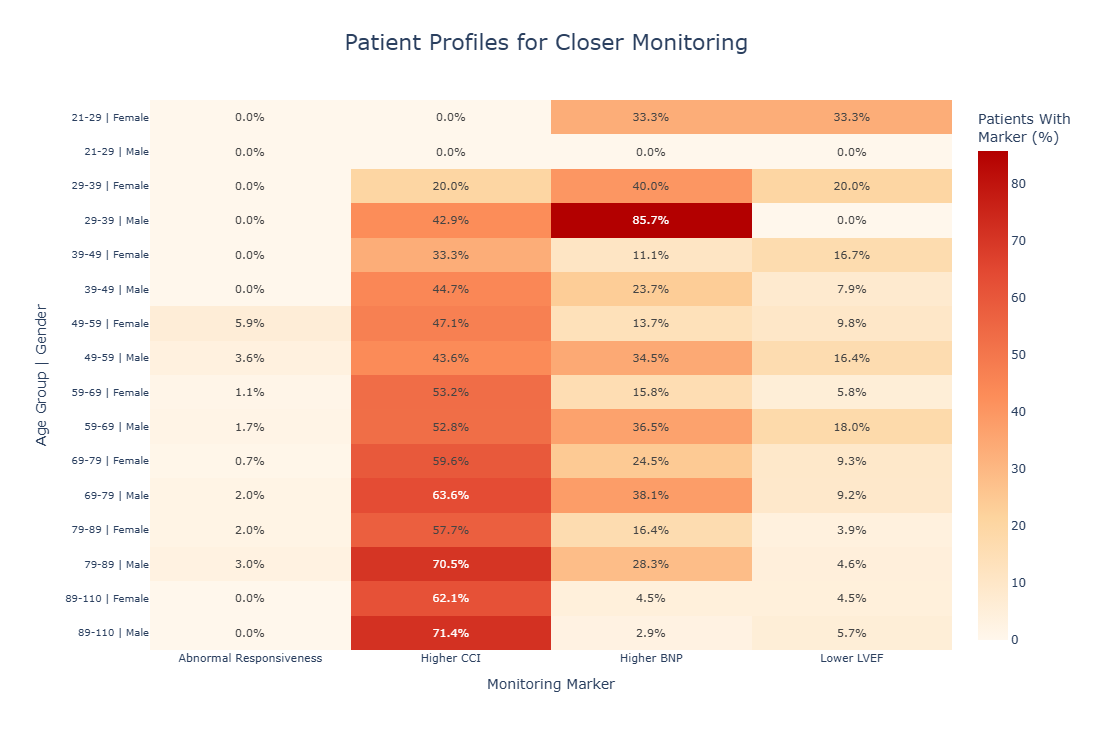


PATIENT MONITORING PRIORITY SUMMARY
--------------------------------


,agecat,gender,Patients,Multiple_Marker_Patients,Average_Marker_Count,Multiple_Marker_Percent,Patient_Profile
0,21-29,Female,3,0,0.666667,0.00,21-29 | Female
1,21-29,Male,1,0,0.000000,0.00,21-29 | Male
14,89-110,Female,66,3,0.712121,4.55,89-110 | Female
15,89-110,Male,35,3,0.800000,8.57,89-110 | Male
4,39-49,Female,18,2,0.611111,11.11,39-49 | Female
12,79-89,Female,409,54,0.799511,13.20,79-89 | Female
8,59-69,Female,190,26,0.757895,13.68,59-69 | Female
5,39-49,Male,38,6,0.763158,15.79,39-49 | Male
10,69-79,Female,421,80,0.940618,19.00,69-79 | Female
6,49-59,Female,51,10,0.764706,19.61,49-59 | Female


In [8]:
# ------------------------------------------------------------
# STEP 2: CHECK REQUIRED COLUMNS
# ------------------------------------------------------------

required_cols = [
    "inpatient_number",
    "agecat",
    "gender",
    "consciousness",
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide"
]

missing_cols = [
    col for col in required_cols
    if col not in df_priority.columns
]

if missing_cols:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are available.")


# ------------------------------------------------------------
# STEP 3: CONVERT CLINICAL MARKERS TO NUMERIC
# ------------------------------------------------------------

numeric_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide"
]

for col in numeric_cols:
    df_priority[col] = pd.to_numeric(
        df_priority[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# STEP 4: CREATE ABNORMAL RESPONSIVENESS FLAG
# ------------------------------------------------------------

# Clear consciousness = 0
# Any other recorded consciousness state = 1

df_priority["Abnormal_Response"] = (
    df_priority["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
).astype(int)


# ------------------------------------------------------------
# STEP 5: CALCULATE DATASET-DERIVED THRESHOLDS
# ------------------------------------------------------------

# Higher CCI = top 25% of CCI values
cci_q75 = df_priority[
    "cci_score"
].quantile(0.75)

# Higher BNP = top 25% of BNP values
bnp_q75 = df_priority[
    "brain_natriuretic_peptide"
].quantile(0.75)

# Lower LVEF = bottom 25% of LVEF values
lvef_q25 = df_priority[
    "lvef"
].quantile(0.25)


# Display thresholds
print("\nDATASET-DERIVED THRESHOLDS")
print("--------------------------------")

print(
    "75th percentile CCI:",
    round(cci_q75, 2)
)

print(
    "75th percentile BNP:",
    round(bnp_q75, 2)
)

print(
    "25th percentile LVEF:",
    round(lvef_q25, 2)
)


# ------------------------------------------------------------
# STEP 6: CREATE MONITORING MARKER FLAGS
# ------------------------------------------------------------

# Higher CCI
df_priority["High_CCI"] = (
    df_priority["cci_score"] >= cci_q75
).astype(int)


# Higher BNP
df_priority["Higher_BNP"] = (
    df_priority[
        "brain_natriuretic_peptide"
    ] >= bnp_q75
).astype(int)


# Lower LVEF
df_priority["Lower_LVEF"] = (
    df_priority["lvef"] <= lvef_q25
).astype(int)


# ------------------------------------------------------------
# STEP 7: CREATE PATIENT PROFILE
# ------------------------------------------------------------

# Combine Age Group and Gender

df_priority["Patient_Profile"] = (
    df_priority["agecat"]
    .astype(str)
    .str.strip()
    + " | "
    + df_priority["gender"]
    .astype(str)
    .str.strip()
)


# ------------------------------------------------------------
# STEP 8: SUMMARIZE RISK MARKERS BY PATIENT PROFILE
# ------------------------------------------------------------

profile_summary = (
    df_priority
    .groupby("Patient_Profile")
    .agg(

        Patients=(
            "inpatient_number",
            "count"
        ),

        Abnormal_Response=(
            "Abnormal_Response",
            "mean"
        ),

        High_CCI=(
            "High_CCI",
            "mean"
        ),

        Higher_BNP=(
            "Higher_BNP",
            "mean"
        ),

        Lower_LVEF=(
            "Lower_LVEF",
            "mean"
        )
    )
)


# ------------------------------------------------------------
# STEP 9: CONVERT MARKER RATES TO PERCENTAGES
# ------------------------------------------------------------

heatmap_data = (
    profile_summary[
        [
            "Abnormal_Response",
            "High_CCI",
            "Higher_BNP",
            "Lower_LVEF"
        ]
    ] * 100
)


# Rename columns for chart
heatmap_data.columns = [
    "Abnormal Responsiveness",
    "Higher CCI",
    "Higher BNP",
    "Lower LVEF"
]


print("\nPATIENT PROFILE RISK MARKERS (%)")
print("--------------------------------")

display(
    heatmap_data.round(1)
)


# ------------------------------------------------------------
# STEP 10: CREATE INTERACTIVE PRESCRIPTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap = go.Figure(

    data=go.Heatmap(

        z=heatmap_data.values,

        x=heatmap_data.columns,

        y=heatmap_data.index,

        # Percentage displayed inside cells
        text=np.round(
            heatmap_data.values,
            1
        ),

        texttemplate="%{text:.1f}%",

        textfont=dict(
            size=11
        ),

        # Custom color scale
        colorscale=[
            [0.00, "#FFF7EC"],
            [0.25, "#FDD49E"],
            [0.50, "#FC8D59"],
            [0.75, "#E34A33"],
            [1.00, "#B30000"]
        ],

        # Interactive hover
        hovertemplate=(
            "<b>Patient Profile:</b> %{y}<br>"
            "<b>Monitoring Marker:</b> %{x}<br>"
            "<b>Patients With Marker:</b> %{z:.1f}%"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Patients With<br>Marker (%)"
        )
    )
)


# ------------------------------------------------------------
# STEP 11: FORMAT INTERACTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap.update_layout(

    title=dict(
        text=(
            "Patient Profiles for Closer Monitoring"
        ),
        x=0.5,
        xanchor="center",
        font=dict(
            size=22
        )
    ),

    xaxis=dict(
        title="Monitoring Marker",
        tickfont=dict(size=11)
    ),

    yaxis=dict(
        title="Age Group | Gender",
        tickfont=dict(size=10),
        autorange="reversed"
    ),

    width=1000,
    height=750,

    template="plotly_white",

    margin=dict(
        l=150,
        r=100,
        t=100,
        b=100
    )
)


# Display interactive heatmap
fig_heatmap.show()


# ------------------------------------------------------------
# STEP 12: CREATE TOTAL MARKER COUNT FOR EACH PATIENT
# ------------------------------------------------------------

marker_cols = [
    "Abnormal_Response",
    "High_CCI",
    "Higher_BNP",
    "Lower_LVEF"
]


df_priority["Marker_Count"] = (
    df_priority[
        marker_cols
    ].sum(axis=1)
)


# ------------------------------------------------------------
# STEP 13: IDENTIFY PATIENTS WITH MULTIPLE MARKERS
# ------------------------------------------------------------

# Patient has multiple markers when 2 or more
# monitoring indicators are present

df_priority["Multiple_Markers"] = (
    df_priority["Marker_Count"] >= 2
).astype(int)


# ------------------------------------------------------------
# STEP 14: CREATE MONITORING PRIORITY LEVEL
# ------------------------------------------------------------

def assign_priority(marker_count):

    if marker_count >= 3:
        return "High Priority"

    elif marker_count == 2:
        return "Moderate Priority"

    else:
        return "Routine Priority"


df_priority["Monitoring_Priority"] = (
    df_priority["Marker_Count"]
    .apply(assign_priority)
)


# ------------------------------------------------------------
# STEP 15: CREATE PRIORITY SUMMARY BY AGE AND GENDER
# ------------------------------------------------------------

priority_summary = (
    df_priority
    .groupby(
        ["agecat", "gender"]
    )
    .agg(

        Patients=(
            "inpatient_number",
            "count"
        ),

        Multiple_Marker_Patients=(
            "Multiple_Markers",
            "sum"
        ),

        Average_Marker_Count=(
            "Marker_Count",
            "mean"
        )
    )
    .reset_index()
)


# ------------------------------------------------------------
# STEP 16: CALCULATE MULTIPLE-MARKER PERCENTAGE
# ------------------------------------------------------------

priority_summary[
    "Multiple_Marker_Percent"
] = (

    priority_summary[
        "Multiple_Marker_Patients"
    ]

    /

    priority_summary[
        "Patients"
    ]

    * 100

).round(2)


# ------------------------------------------------------------
# STEP 17: CREATE PATIENT PROFILE FOR BAR CHART
# ------------------------------------------------------------

priority_summary["Patient_Profile"] = (

    priority_summary[
        "agecat"
    ].astype(str)

    + " | "

    + priority_summary[
        "gender"
    ].astype(str)
)


# ------------------------------------------------------------
# STEP 18: SORT PATIENT PROFILES
# ------------------------------------------------------------

priority_summary = (
    priority_summary
    .sort_values(
        "Multiple_Marker_Percent",
        ascending=True
    )
)


print(
    "\nPATIENT MONITORING PRIORITY SUMMARY"
)

print(
    "--------------------------------"
)

display(
    priority_summary
)


# ------------------------------------------------------------
# STEP 19: CREATE INTERACTIVE PRIORITY BAR CHART
# ------------------------------------------------------------

fig_priority = px.bar(

    priority_summary,

    x="Multiple_Marker_Percent",

    y="Patient_Profile",

    orientation="h",

    color="Multiple_Marker_Percent",

    color_continuous_scale=[
        "#FFF7EC",
        "#FDD49E",
        "#FC8D59",
        "#E34A33",
        "#B30000"
    ],

    text="Multiple_Marker_Percent",

    hover_data={

        "Patients": True,

        "Multiple_Marker_Patients":
            True,

        "Average_Marker_Count":
            ":.2f",

        "Multiple_Marker_Percent":
            ":.1f"
    },

    labels={

        "Multiple_Marker_Percent":
            "Patients With Multiple Risk Markers (%)",

        "Patient_Profile":
            "Age Group | Gender"
    },

    title=(
        "Patient Profiles Prioritized "
        "for Closer Monitoring"
    )
)








<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> From your previous analysis, abnormal responsiveness is uncommon overall: 34 patients were classified as abnormal compared with 1,974 Clear/Normal patients. By raw count, abnormal responsiveness was most concentrated in the 79–89 age group, with 15 abnormal cases, and your comorbidity analysis also showed increasing multiple-comorbidity prevalence among older groups, reaching 26.73% in the 89–110 group.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 2 :  Which patient groups warrant closer cardiac assessment based on high BNP and low LVEF patterns?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a useful prescriptive-analysis question because it moves from simply describing BNP or LVEF individually to identifying patient groups where both patterns occur together. BNP provides biomarker information relevant to cardiac stress/heart-failure assessment, while LVEF describes ventricular pumping function. AHA guidance also emphasizes that EF is only one part of heart-failure assessment, so combining markers is more informative than treating either measure alone as definitive.</p>

In [9]:
# -------------------------------------------------------
# Step 1. Merge Demography, Cardiac Condition, Labs 
# -------------------------------------------------------
df_cardiac = (
    labs[
        ["inpatient_number", "brain_natriuretic_peptide"]
    ]
    .merge(
        cc[
            ["inpatient_number", "lvef"]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        demo[
            ["inpatient_number", "agecat", "gender"]
        ],
        on="inpatient_number",
        how="inner"
    )
)

print(df_cardiac.shape)
df_cardiac.head()

(2008, 5)


,inpatient_number,brain_natriuretic_peptide,lvef,agecat,gender
0,857781,1500.17,NaN,69-79,Male
1,743087,361.70,NaN,69-79,Female
2,866418,293.95,NaN,59-69,Male
3,775928,1071.40,NaN,69-79,Male
4,810128,372.87,NaN,69-79,Female


Higher BNP threshold: 1736.98
Lower LVEF threshold: 41.0
Cardiac_Priority
0    548
1     78
Name: count, dtype: int64


,agecat,gender,Total_Patients,Priority_Patients,Priority_Percent,Median_BNP,Median_LVEF
0,21-29,Female,2,0,0.00,3251.32,34.0
1,21-29,Male,1,0,0.00,441.98,52.0
2,29-39,Female,3,1,33.33,2400.35,71.0
3,39-49,Female,8,1,12.50,724.44,50.0
4,39-49,Male,7,1,14.29,1371.36,49.0
5,49-59,Female,19,2,10.53,359.83,49.0
6,49-59,Male,17,3,17.65,603.18,41.0
7,59-69,Female,59,4,6.78,386.81,50.0
8,59-69,Male,63,17,26.98,1140.78,41.0
9,69-79,Female,138,21,15.22,712.72,52.0


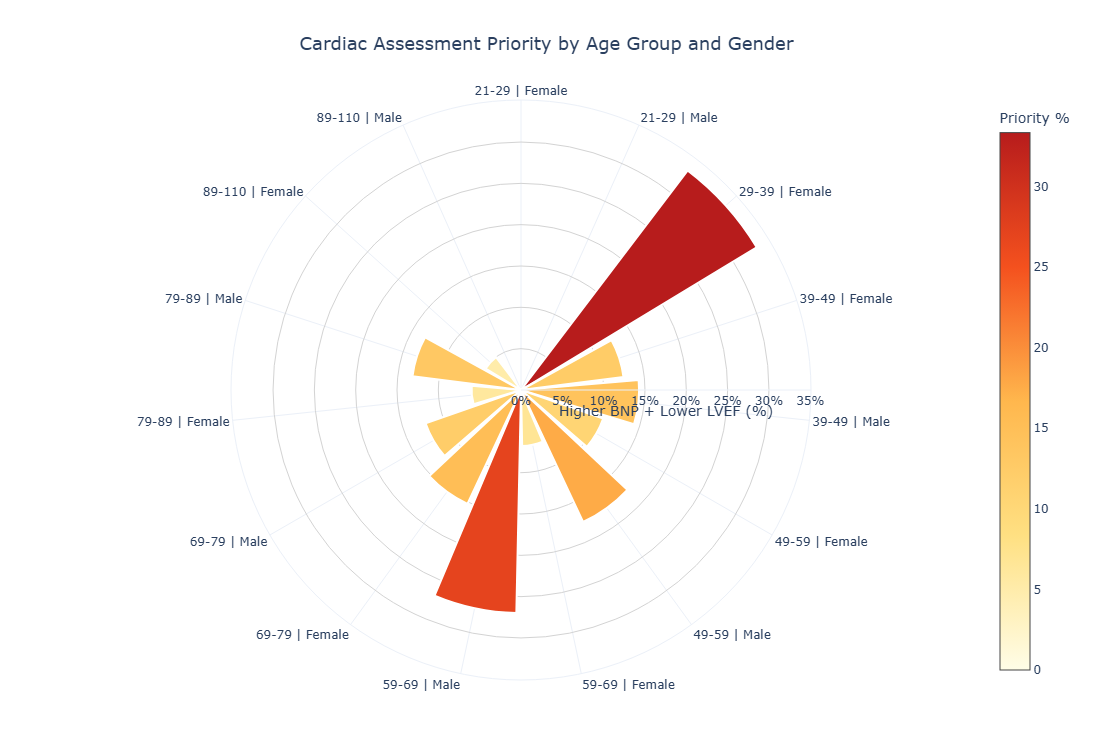

In [10]:
# -------------------------------------------------------
# Step 2. Convert BNP and LVEF to numeric
# -------------------------------------------------------
df_cardiac["brain_natriuretic_peptide"] = pd.to_numeric(
    df_cardiac["brain_natriuretic_peptide"],
    errors="coerce"
)

df_cardiac["lvef"] = pd.to_numeric(
    df_cardiac["lvef"],
    errors="coerce"
)

df_cardiac = df_cardiac.dropna(
    subset=[
        "brain_natriuretic_peptide",
        "lvef",
        "agecat",
        "gender"
    ]
)

# -------------------------------------------------------
# Step 3. Define Higher BNP and Lower LVEF
# -------------------------------------------------------
bnp_q75 = df_cardiac[
    "brain_natriuretic_peptide"
].quantile(0.75)

lvef_q25 = df_cardiac[
    "lvef"
].quantile(0.25)

print(
    "Higher BNP threshold:",
    round(bnp_q75, 2)
)

print(
    "Lower LVEF threshold:",
    round(lvef_q25, 2)
)

# -------------------------------------------------------
# Step 4. Identify patients with both patterns
# -------------------------------------------------------
df_cardiac["Higher_BNP"] = (
    df_cardiac["brain_natriuretic_peptide"]
    >= bnp_q75
)

df_cardiac["Lower_LVEF"] = (
    df_cardiac["lvef"]
    <= lvef_q25
)

df_cardiac["Cardiac_Priority"] = (
    df_cardiac["Higher_BNP"]
    &
    df_cardiac["Lower_LVEF"]
).astype(int)
print(
    df_cardiac["Cardiac_Priority"]
    .value_counts()
)

# -------------------------------------------------------
# Step 5. Calculate the percentage for each patient group
# -------------------------------------------------------
polar_data = (
    df_cardiac
    .groupby(
        ["agecat", "gender"],
        observed=True
    )
    .agg(
        Total_Patients=(
            "inpatient_number",
            "count"
        ),

        Priority_Patients=(
            "Cardiac_Priority",
            "sum"
        ),

        Priority_Percent=(
            "Cardiac_Priority",
            "mean"
        ),

        Median_BNP=(
            "brain_natriuretic_peptide",
            "median"
        ),

        Median_LVEF=(
            "lvef",
            "median"
        )
    )
    .reset_index()
)

polar_data["Priority_Percent"] = (
    polar_data["Priority_Percent"] * 100
)

polar_data = polar_data.sort_values(
    ["agecat", "gender"]
)

display(
    polar_data.round(2)
)

# -----------------------------------------------------------------
# Step 6. Create labels for the radial heatmap
# -----------------------------------------------------------------
polar_data["Patient_Group"] = (
    polar_data["agecat"].astype(str)
    + " | "
    + polar_data["gender"].astype(str)
)

# -----------------------------------------------------------------
# Step 7. Create the interactive Radial / Polar Heatmap
# -----------------------------------------------------------------

fig = go.Figure()

fig.add_trace(
    go.Barpolar(

        # Length of each sector
        r=polar_data["Priority_Percent"],

        # Patient groups around circle
        theta=polar_data["Patient_Group"],

        # Color based on priority percentage
        marker=dict(

            color=polar_data[
                "Priority_Percent"
            ],

            colorscale=[
                [0.00, "#FFFDE7"],
                [0.25, "#FFE082"],
                [0.50, "#FFB74D"],
                [0.75, "#F4511E"],
                [1.00, "#B71C1C"]
            ],

            colorbar=dict(
                title="Priority %"
            ),

            line=dict(
                color="white",
                width=2
            )
        ),

        customdata=polar_data[
            [
                "Total_Patients",
                "Priority_Patients",
                "Median_BNP",
                "Median_LVEF"
            ]
        ],

        hovertemplate=(
            "<b>%{theta}</b><br><br>"
            "Higher BNP + Lower LVEF: %{r:.1f}%<br>"
            "Total Patients: %{customdata[0]}<br>"
            "Priority Patients: %{customdata[1]}<br>"
            "Median BNP: %{customdata[2]:.2f}<br>"
            "Median LVEF: %{customdata[3]:.2f}"
            "<extra></extra>"
        )
    )
)

# -----------------------------------------------------------------
# Step 7. Format the chart
# -----------------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Cardiac Assessment Priority by "
            "Age Group and Gender"
        ),
        x=0.5,
        font=dict(size=18)
    ),

    polar=dict(

        radialaxis=dict(
            title="Higher BNP + Lower LVEF (%)",
            ticksuffix="%",
            showgrid=True,
            gridcolor="lightgray"
        ),

        angularaxis=dict(
            direction="clockwise",
            rotation=90
        )
    ),

    template="plotly_white",

    width=900,
    height=750,

    margin=dict(
        l=70,
        r=120,
        t=100,
        b=70
    )
)

fig.show()

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The radial heatmap identifies the age–gender groups with the highest concentration of the combined higher-BNP and lower-LVEF pattern. Darker and longer sectors represent groups with a greater percentage of patients meeting both exploratory criteria, highlighting patient groups that may warrant closer analytical cardiac assessment.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 3  :  Which laboratory and cardiac markers show the strongest relationships with one another and with patient comorbidity burden?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>This is a useful prescriptive-analysis question because patients often have multiple abnormalities occurring together. Examining correlations helps identify which cardiac, renal, and laboratory markers tend to move together and which markers are most closely associated with greater comorbidity burden.
A correlation heatmap is particularly suitable because it compares all marker pairs simultaneously, making clusters of related markers immediately visible. Similar biomarker/multimorbidity research uses Spearman correlation matrices and heatmaps to identify shared and distinct biomarker relationships.</p>

In [11]:
# ------------------------------------------------------------
# Step 1.  Merge Patient History, Cardiac Condition, Labs 
# ------------------------------------------------------------

df_corr = (
    ph[
        [
            "inpatient_number",
            "cci_score"
        ]
    ]
    .merge(
        cc[
            [
                "inpatient_number",
                "lvef"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        labs[
            [
                "inpatient_number",
                "brain_natriuretic_peptide",
                "high_sensitivity_troponin",
                "creatinine_enzymatic_method",
                "glomerular_filtration_rate"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
)


Missing Values
----------------------------------------
cci_score                         5
lvef                           1373
brain_natriuretic_peptide        35
high_sensitivity_troponin        79
creatinine_enzymatic_method      23
glomerular_filtration_rate       63
dtype: int64

Spearman Correlation Matrix
----------------------------------------


,CCI Score,LVEF,BNP,Troponin,Creatinine,GFR
CCI Score,1.00,0.03,0.06,0.13,0.25,-0.25
LVEF,0.03,1.00,-0.54,-0.31,-0.09,0.01
BNP,0.06,-0.54,1.00,0.53,0.25,-0.18
Troponin,0.13,-0.31,0.53,1.00,0.33,-0.28
Creatinine,0.25,-0.09,0.25,0.33,1.00,-0.94
GFR,-0.25,0.01,-0.18,-0.28,-0.94,1.00


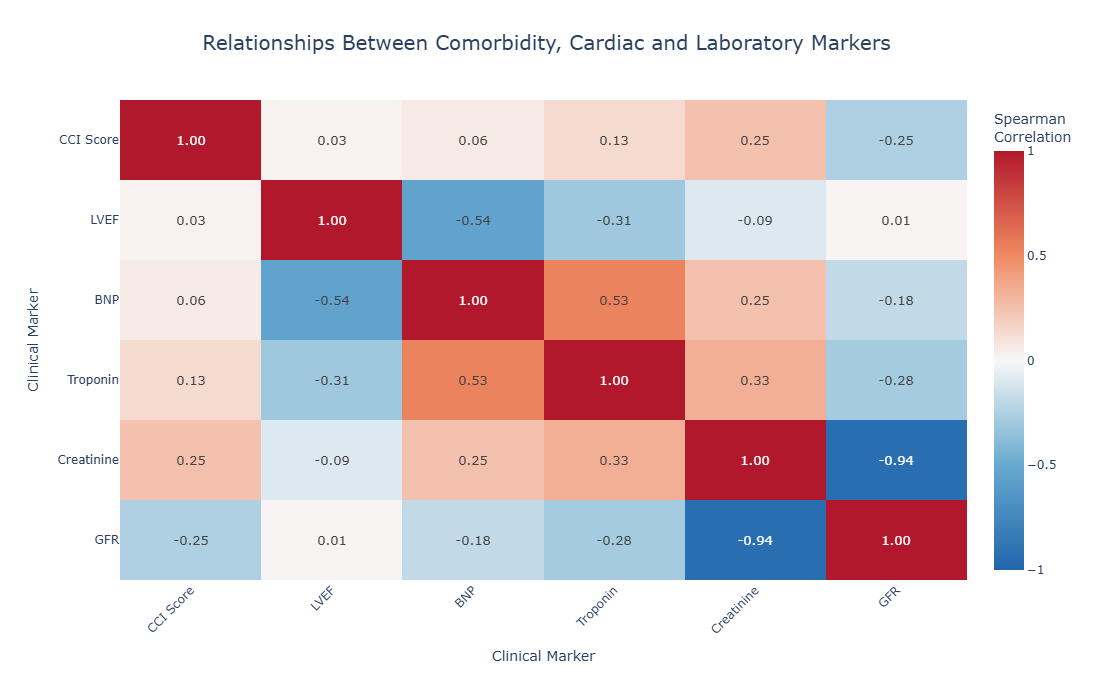


Strongest Relationships
----------------------------------------


,Marker_1,Marker_2,Correlation,Relationship
0,Creatinine,GFR,-0.944,Negative
1,LVEF,BNP,-0.545,Negative
2,BNP,Troponin,0.530,Positive
3,Troponin,Creatinine,0.330,Positive
4,LVEF,Troponin,-0.307,Negative
5,Troponin,GFR,-0.285,Negative
6,CCI Score,GFR,-0.250,Negative
7,BNP,Creatinine,0.247,Positive
8,CCI Score,Creatinine,0.247,Positive
9,BNP,GFR,-0.183,Negative


In [12]:
# ------------------------------------------------------------
# STEP 2: DEFINE VARIABLES FOR ANALYSIS
# ------------------------------------------------------------

analysis_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate"
]


# ------------------------------------------------------------
# STEP 3: CONVERT VARIABLES TO NUMERIC
# ------------------------------------------------------------

for col in analysis_cols:
    
    df_corr[col] = pd.to_numeric(
        df_corr[col],
        errors="coerce"
    )


# ------------------------------------------------------------
# STEP 4: CHECK MISSING VALUES
# ------------------------------------------------------------

print("Missing Values")
print("-" * 40)

print(
    df_corr[
        analysis_cols
    ].isnull().sum()
)


# ------------------------------------------------------------
# STEP 5: CREATE SPEARMAN CORRELATION MATRIX
# ------------------------------------------------------------

correlation_matrix = (
    df_corr[
        analysis_cols
    ]
    .corr(
        method="spearman"
    )
)


# ------------------------------------------------------------
# STEP 6: GIVE VARIABLES READABLE NAMES
# ------------------------------------------------------------

readable_names = {
    
    "cci_score":
        "CCI Score",
    
    "lvef":
        "LVEF",
    
    "brain_natriuretic_peptide":
        "BNP",
    
    "high_sensitivity_troponin":
        "Troponin",
    
    "creatinine_enzymatic_method":
        "Creatinine",
    
    "glomerular_filtration_rate":
        "GFR"
}


correlation_matrix = (
    correlation_matrix.rename(
        index=readable_names,
        columns=readable_names
    )
)


# Display correlation table
print("\nSpearman Correlation Matrix")
print("-" * 40)

display(
    correlation_matrix.round(2)
)


# ------------------------------------------------------------
# STEP 7: CREATE INTERACTIVE CORRELATION HEATMAP
# ------------------------------------------------------------

fig_heatmap = go.Figure(

    data=go.Heatmap(

        # Correlation values
        z=correlation_matrix.values,

        # Marker names
        x=correlation_matrix.columns,

        y=correlation_matrix.index,

        # Display values inside cells
        text=np.round(
            correlation_matrix.values,
            2
        ),

        texttemplate="%{text:.2f}",

        textfont=dict(
            size=13
        ),

        # Diverging color scale
        colorscale=[
            [0.00, "#2166AC"],
            [0.25, "#67A9CF"],
            [0.50, "#F7F7F7"],
            [0.75, "#EF8A62"],
            [1.00, "#B2182B"]
        ],

        # Correlation range
        zmin=-1,
        zmax=1,
        zmid=0,

        # Interactive hover
        hovertemplate=(
            "<b>Marker 1:</b> %{y}<br>"
            "<b>Marker 2:</b> %{x}<br>"
            "<b>Spearman Correlation:</b> %{z:.3f}"
            "<extra></extra>"
        ),

        colorbar=dict(
            title="Spearman<br>Correlation",
            tickvals=[
                -1,
                -0.5,
                0,
                0.5,
                1
            ]
        )
    )
)


# ------------------------------------------------------------
# STEP 8: FORMAT INTERACTIVE HEATMAP
# ------------------------------------------------------------

fig_heatmap.update_layout(

    title=dict(

        text=(
            "Relationships Between Comorbidity, "
            "Cardiac and Laboratory Markers"
        ),

        x=0.5,

        xanchor="center",

        font=dict(
            size=20
        )
    ),

    xaxis=dict(

        title="Clinical Marker",

        tickangle=-45,

        side="bottom"
    ),

    yaxis=dict(

        title="Clinical Marker",

        autorange="reversed"
    ),

    width=850,

    height=700,

    template="plotly_white",

    margin=dict(
        l=120,
        r=100,
        t=100,
        b=120
    )
)


fig_heatmap.show()


# ------------------------------------------------------------
# STEP 9: FIND UNIQUE CORRELATION PAIRS
# ------------------------------------------------------------

corr_pairs = (

    correlation_matrix
    .stack()
    .reset_index()
)


corr_pairs.columns = [
    "Marker_1",
    "Marker_2",
    "Correlation"
]


# ------------------------------------------------------------
# STEP 10: REMOVE SAME-VARIABLE CORRELATIONS
# ------------------------------------------------------------

corr_pairs = corr_pairs[

    corr_pairs["Marker_1"]
    !=
    corr_pairs["Marker_2"]

].copy()


# ------------------------------------------------------------
# STEP 11: REMOVE DUPLICATE PAIRS
# ------------------------------------------------------------

corr_pairs["Pair"] = (

    corr_pairs.apply(

        lambda row:

        " | ".join(
            sorted(
                [
                    row["Marker_1"],
                    row["Marker_2"]
                ]
            )
        ),

        axis=1
    )
)


corr_pairs = (

    corr_pairs
    .drop_duplicates(
        subset="Pair"
    )
    .copy()
)


# ------------------------------------------------------------
# STEP 12: CALCULATE ABSOLUTE CORRELATION
# ------------------------------------------------------------

corr_pairs[
    "Absolute_Correlation"
] = (

    corr_pairs[
        "Correlation"
    ].abs()
)


# Sort strongest to weakest
corr_pairs = (

    corr_pairs
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


# ------------------------------------------------------------
# STEP 13: CLASSIFY DIRECTION
# ------------------------------------------------------------

corr_pairs[
    "Relationship"
] = np.where(

    corr_pairs[
        "Correlation"
    ] >= 0,

    "Positive",

    "Negative"
)


# Display results
print(
    "\nStrongest Relationships"
)

print("-" * 40)


display(

    corr_pairs[
        [
            "Marker_1",
            "Marker_2",
            "Correlation",
            "Relationship"
        ]
    ]
    .round(3)
)


# ------------------------------------------------------------
# STEP 14: CREATE TOP RELATIONSHIPS DATA
# ------------------------------------------------------------

# Select strongest 10 relationships
top_relationships = (

    corr_pairs
    .head(10)
    .copy()
)


# Use readable pair labels
top_relationships[
    "Relationship_Pair"
] = (

    top_relationships[
        "Marker_1"
    ]

    + " ↔ "

    + top_relationships[
        "Marker_2"
    ]
)


# Reverse for horizontal chart
top_relationships = (

    top_relationships
    .sort_values(
        "Absolute_Correlation",
        ascending=True
    )
)


# ------------------------------------------------------------
# STEP 15: CREATE INTERACTIVE RANKED BAR CHART
# ------------------------------------------------------------

fig_pairs = px.bar(

    top_relationships,

    x="Absolute_Correlation",

    y="Relationship_Pair",

    orientation="h",

    color="Relationship",

    color_discrete_map={
        "Positive": "#D95F59",
        "Negative": "#4C78A8"
    },

    text="Correlation",

    hover_data={
        "Marker_1": True,
        "Marker_2": True,
        "Correlation": ":.3f",
        "Absolute_Correlation": ":.3f",
        "Relationship": True
    },

    title=(
        "Strongest Relationships Between "
        "Clinical and Cardiac Markers"
    ),

    labels={

        "Absolute_Correlation":
            "Absolute Spearman Correlation",

        "Relationship_Pair":
            "Marker Relationship"
    }
)




<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The correlation analysis identifies the marker pair with the strongest relationship across the cardiac and laboratory measures and separately identifies the marker most strongly associated with CCI score. Strong positive correlations indicate markers that tend to increase together, while strong negative correlations indicate that one tends to decrease as the other increases. These relationships highlight combinations of markers that may be useful for coordinated analytical review in patients with greater comorbidity burden.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 4  : Which laboratory markers are most strongly associated with abnormal patient responsiveness and therefore may be useful for prioritizing follow-up?</b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>The lollipop chart directly answers “which laboratory markers are strongest?” by ranking markers according to their association with abnormal responsiveness. Unlike a correlation heatmap, which is more useful for many pairwise relationships, this chart focuses on one target outcome and makes the strongest signals immediately visible.</p>

In [13]:
# -------------------------------------------------------
# Step 1. Merge responsiveness and labs
# -------------------------------------------------------

df_lab = labs.merge(
    resp[
        [
            "inpatient_number",
            "consciousness"
        ]
    ],
    on="inpatient_number",
    how="inner"
)

Abnormal_Response
0    1974
1      34
Name: count, dtype: int64


,Marker,Association,Absolute_Association
7,Partial Oxygen Pressure,0.008,0.008
6,Respiration,0.020,0.020
5,Oxygen Saturation,-0.029,0.029
0,BNP,0.048,0.048
3,Urea,0.104,0.104
4,GFR,-0.106,0.106
2,Creatinine,0.107,0.107
1,Troponin,0.121,0.121


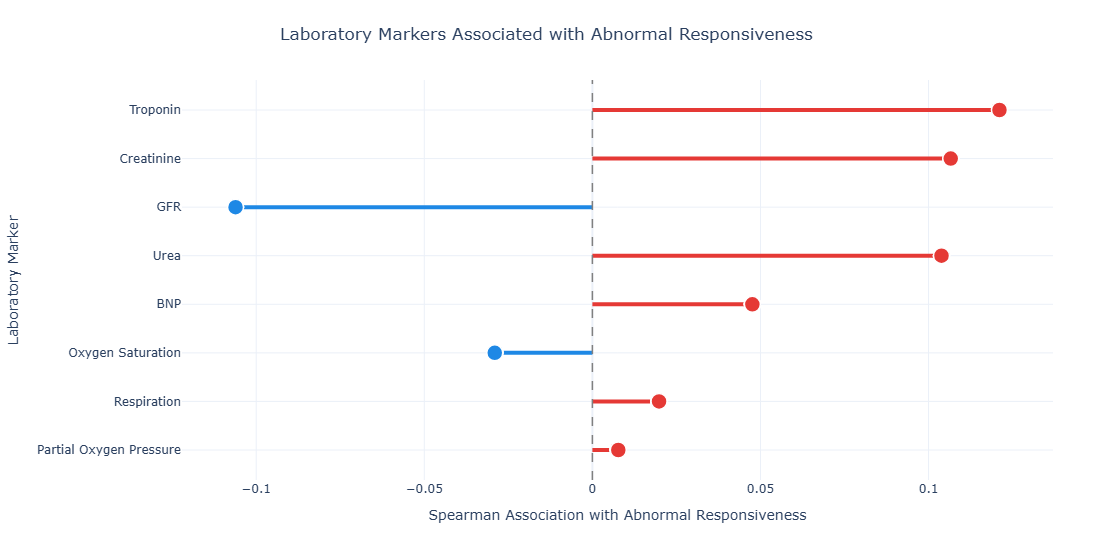

In [14]:
# -------------------------------------------------------
# Step 2 Create Normal/Abnormal responsiveness
# -------------------------------------------------------
df_lab["Abnormal_Response"] = (
    df_lab["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
).astype(int)

print(
    df_lab["Abnormal_Response"]
    .value_counts()
)

# -------------------------------------------------------
# Step 3. Select laboratory markers
# -------------------------------------------------------

lab_markers = [
    "brain_natriuretic_peptide",
    "high_sensitivity_troponin",
    "creatinine_enzymatic_method",
    "urea",
    "glomerular_filtration_rate",
    "oxygen_saturation",
    "respiration",
    "partial_oxygen_pressure"
]

for col in lab_markers:

    df_lab[col] = pd.to_numeric(
        df_lab[col],
        errors="coerce"
    )
    
# ------------------------------------------------------------
# Step 4. Calculate association with abnormal responsiveness
# ------------------------------------------------------------

associations = []

for marker in lab_markers:

    corr = df_lab[
        marker
    ].corr(
        df_lab["Abnormal_Response"],
        method="spearman"
    )

    associations.append(
        {
            "Marker": marker,
            "Association": corr,
            "Absolute_Association": abs(corr)
        }
    )

association_df = pd.DataFrame(
    associations
)

# -------------------------------------------------------
# Step 5. Give markers readable names
# -------------------------------------------------------

name_map = {

    "brain_natriuretic_peptide":
        "BNP",

    "high_sensitivity_troponin":
        "Troponin",

    "creatinine_enzymatic_method":
        "Creatinine",

    "urea":
        "Urea",

    "glomerular_filtration_rate":
        "GFR",

    "oxygen_saturation":
        "Oxygen Saturation",

    "respiration":
        "Respiration",

    "partial_oxygen_pressure":
        "Partial Oxygen Pressure"
}

association_df["Marker"] = (
    association_df["Marker"]
    .replace(name_map)
)

# -------------------------------------------------------
# Step 6. Rank the markers
# -------------------------------------------------------

association_df = (
    association_df
    .dropna(
        subset=["Association"]
    )
    .sort_values(
        "Absolute_Association",
        ascending=True
    )
)

display(
    association_df.round(3)
)

# -------------------------------------------------------
# Step 7. Create interactive colored lollipop chart
# -------------------------------------------------------

colors = [
    "#E53935"
    if x > 0
    else "#1E88E5"
    for x in association_df[
        "Association"
    ]
]

fig = go.Figure()

for _, row in association_df.iterrows():

    line_color = (
        "#E53935"
        if row["Association"] > 0
        else "#1E88E5"
    )

    fig.add_trace(
        go.Scatter(
            x=[
                0,
                row["Association"]
            ],

            y=[
                row["Marker"],
                row["Marker"]
            ],

            mode="lines",

            line=dict(
                color=line_color,
                width=4
            ),

            hoverinfo="skip",

            showlegend=False
        )
    )

    fig.add_trace(
    go.Scatter(

        x=association_df[
            "Association"
        ],

        y=association_df[
            "Marker"
        ],

        mode="markers",

        marker=dict(
            size=16,
            color=colors,

            line=dict(
                color="white",
                width=1.5
            )
        ),

        customdata=association_df[
            "Absolute_Association"
        ],

        hovertemplate=(
            "<b>%{y}</b><br>"
            "Association: %{x:.3f}<br>"
            "Absolute Strength: %{customdata:.3f}"
            "<extra></extra>"
        ),

        showlegend=False
    )
)

# -------------------------------------------------------
# Step 8. Add zero reference line
# -------------------------------------------------------

fig.add_vline(
    x=0,
    line_width=1.5,
    line_dash="dash",
    line_color="gray"
)

# -------------------------------------------------------
# Step 9. Format the interactive chart
# -------------------------------------------------------

fig.update_layout(

    title=dict(
        text=(
            "Laboratory Markers Associated with "
            "Abnormal Responsiveness"
        ),
        x=0.5
    ),

    xaxis_title=(
        "Spearman Association with "
        "Abnormal Responsiveness"
    ),

    yaxis_title=(
        "Laboratory Marker"
    ),

    template="plotly_white",

    width=900,
    height=550,

    hoverlabel=dict(
        font_size=13
    ),

    margin=dict(
        l=170,
        r=40,
        t=80,
        b=70
    )
)

fig.show()






<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight :</b> The ranked lollipop chart identifies the laboratory markers with the strongest positive or negative associations with abnormal responsiveness. Markers positioned farther from zero show stronger relationships and may therefore be useful candidates for closer analytical follow-up. Positive and negative directions should be interpreted according to the clinical meaning of each marker, rather than treating one color as universally better or worse.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 5  : Which patient profiles should be prioritized for intensive monitoring and post-discharge follow-up based on demographics, medical history, medication use, laboratory abnormalities, cardiac complications, responsiveness, and hospitalization outcomes? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>A bubble priority matrix is especially suitable because your question combines many variables from all seven tables. Instead of displaying seven separate charts, it converts the major indicators into interpretable risk dimensions and visually identifies the patient profiles that warrant greater attention.</p>

In [17]:
# -------------------------------------------------------
# 1. Merge All 7 Tables
# -------------------------------------------------------
#Convert important columns to numeric

labs["brain_natriuretic_peptide"] = pd.to_numeric(
    labs["brain_natriuretic_peptide"],
    errors="coerce"
)

cc["lvef"] = pd.to_numeric(
    cc["lvef"],
    errors="coerce"
)

cc["nyha_cardiac_function_classification"] = pd.to_numeric(
    cc["nyha_cardiac_function_classification"],
    errors="coerce"
)

ph["cci_score"] = pd.to_numeric(
    ph["cci_score"],
    errors="coerce"
)

resp["gcs"] = pd.to_numeric(
    resp["gcs"],
    errors="coerce"
)

#Calculate medication burden
med_count = (
    pp
    .groupby("inpatient_number")["drug_name"]
    .nunique()
    .reset_index(name="medication_count")
)

med_count.head()

# Select the important fields

demo_small = demo[
    ["inpatient_number", "agecat", "gender", "bmi"]
]

history_small = ph[
    [
        "inpatient_number",
        "cci_score",
        "diabetes",
        "moderate_to_severe_chronic_kidney_disease",
        "acute_renal_failure"
    ]
]

labs_small = labs[
    [
        "inpatient_number",
        "brain_natriuretic_peptide",
        "creatinine_enzymatic_method",
        "glomerular_filtration_rate"
    ]
]

cardiac_small = cc[
    [
        "inpatient_number",
        "lvef",
        "nyha_cardiac_function_classification",
        "congestive_heart_failure"
    ]
]

response_small = resp[
    ["inpatient_number", "gcs", "consciousness"]
]

hospital_small = hd[
    [
        "inpatient_number",
        "visit_times",
        "re_admission_within_28_days",
        "re_admission_within_3_months",
        "return_to_emergency_department_within_6_months"
    ]
]

# Merge all 7 tables

df = (
    demo_small
    .merge(history_small, on="inpatient_number", how="left")
    .merge(med_count, on="inpatient_number", how="left")
    .merge(labs_small, on="inpatient_number", how="left")
    .merge(cardiac_small, on="inpatient_number", how="left")
    .merge(response_small, on="inpatient_number", how="left")
    .merge(hospital_small, on="inpatient_number", how="left")
)

print("Final dataset shape:", df.shape)

df.head()

Final dataset shape: (2008, 21)


,inpatient_number,agecat,gender,bmi,cci_score,diabetes,moderate_to_severe_chronic_kidney_disease,acute_renal_failure,medication_count,brain_natriuretic_peptide,...,glomerular_filtration_rate,lvef,nyha_cardiac_function_classification,congestive_heart_failure,gcs,consciousness,visit_times,re_admission_within_28_days,re_admission_within_3_months,return_to_emergency_department_within_6_months
0,827040,69-79,Female,23.781213,1.0,0,0.0,0,3.0,70.83,...,71.88,NaN,3,1,15,Clear,1,0,0,1.0
1,857781,69-79,Male,18.590125,2.0,1,0.0,0,13.0,1500.17,...,58.57,NaN,3,0,15,Clear,1,0,0,0.0
2,743087,69-79,Female,19.195303,0.0,0,0.0,0,3.0,361.70,...,85.43,NaN,3,0,15,Clear,1,0,0,0.0
3,866418,59-69,Male,24.221453,0.0,0,0.0,0,7.0,293.95,...,31.51,NaN,2,0,15,Clear,2,0,0,0.0
4,775928,69-79,Male,22.491349,2.0,0,1.0,0,8.0,1071.40,...,58.01,NaN,3,0,15,Clear,1,1,1,1.0


Cardiac/Lab Risk Cutoff: 51.26
Clinical Risk Cutoff: 35.76


,Priority_Level,Patients
0,Critical Priority,680
1,High Clinical Priority,517
2,Routine Priority,489
3,High Cardiac/Lab Priority,322


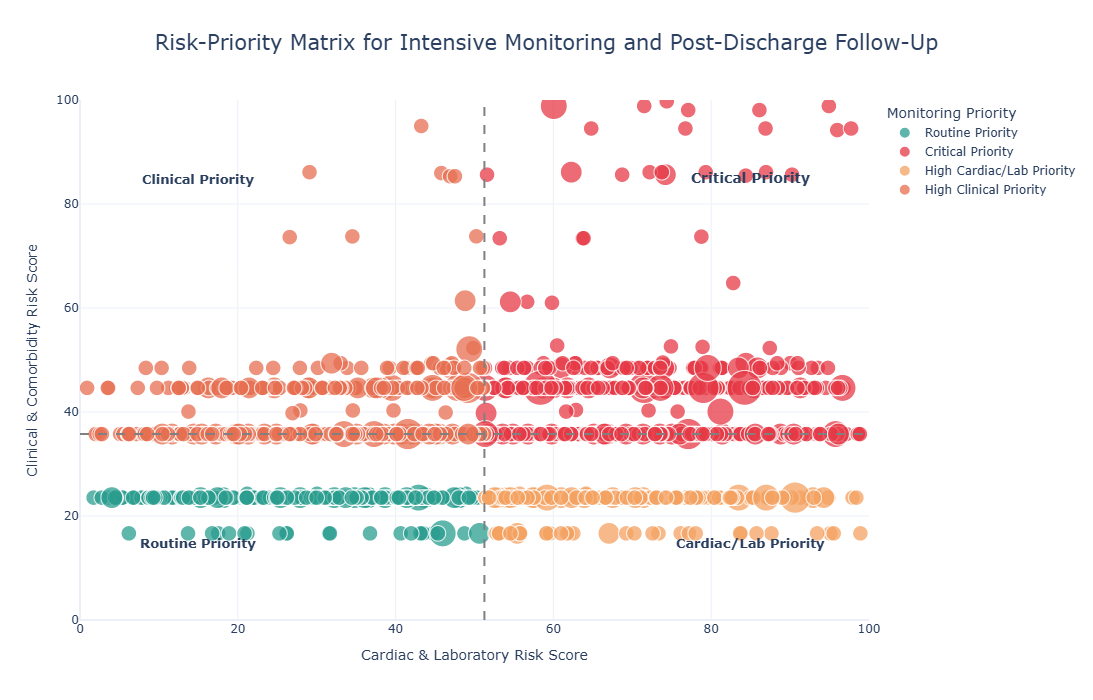


Highest-Priority Patient Profiles:


,inpatient_number,Patient_Profile,Cardiac_Lab_Risk,Clinical_Risk,Hospital_Burden,Priority_Level
1028,790433,69-79 | Male,74.366242,99.750665,1,Critical Priority
1111,730841,79-89 | Female,94.913835,98.843692,1,Critical Priority
1997,750447,79-89 | Male,71.507708,98.843692,1,Critical Priority
1058,834443,79-89 | Male,60.050351,98.843692,3,Critical Priority
1952,736630,59-69 | Female,86.110231,98.063479,1,Critical Priority
1963,789663,49-59 | Male,77.082506,98.063479,1,Critical Priority
1391,828678,69-79 | Male,97.733108,94.518050,1,Critical Priority
945,788087,79-89 | Male,86.886102,94.518050,1,Critical Priority
784,753274,79-89 | Female,76.731376,94.518050,1,Critical Priority
759,830537,49-59 | Female,64.790922,94.518050,1,Critical Priority


In [19]:
# -------------------------------------------------------
# STEP 1: CREATE WORKING DATAFRAME
# -------------------------------------------------------

risk_df = df.copy()


# -------------------------------------------------------
# STEP 2: SELECT IMPORTANT RISK VARIABLES
# -------------------------------------------------------

numeric_cols = [
    "cci_score",
    "lvef",
    "brain_natriuretic_peptide",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate",
    "gcs"
]


# -------------------------------------------------------
# STEP 3: CONVERT TO NUMERIC
# -------------------------------------------------------

for col in numeric_cols:

    if col in risk_df.columns:

        risk_df[col] = pd.to_numeric(
            risk_df[col],
            errors="coerce"
        )


# -------------------------------------------------------
# STEP 4: CREATE ABNORMAL RESPONSIVENESS FLAG
# -------------------------------------------------------

risk_df["Abnormal_Response"] = np.where(

    risk_df["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .eq("clear"),

    0,
    1
)


# -------------------------------------------------------
# STEP 5: CREATE PERCENTILE-BASED RISK SCORES
# -------------------------------------------------------

# Higher CCI = higher risk
risk_df["CCI_Risk"] = (
    risk_df["cci_score"]
    .rank(pct=True)
)


# Higher BNP = higher risk
risk_df["BNP_Risk"] = (
    risk_df["brain_natriuretic_peptide"]
    .rank(pct=True)
)


# Higher Creatinine = higher risk
risk_df["Creatinine_Risk"] = (
    risk_df["creatinine_enzymatic_method"]
    .rank(pct=True)
)


# Lower GFR = higher risk
risk_df["GFR_Risk"] = (
    1
    -
    risk_df["glomerular_filtration_rate"]
    .rank(pct=True)
)


# Lower LVEF = higher risk
risk_df["LVEF_Risk"] = (
    1
    -
    risk_df["lvef"]
    .rank(pct=True)
)


# Lower GCS = higher risk
risk_df["GCS_Risk"] = (
    1
    -
    risk_df["gcs"]
    .rank(pct=True)
)


# -------------------------------------------------------
# STEP 6: CREATE CARDIAC + LABORATORY RISK SCORE
# -------------------------------------------------------

risk_df["Cardiac_Lab_Risk"] = (

    risk_df[
        [
            "BNP_Risk",
            "Creatinine_Risk",
            "GFR_Risk",
            "LVEF_Risk"
        ]
    ]

    .mean(axis=1)

    * 100
)


# -------------------------------------------------------
# STEP 7: CREATE CLINICAL / COMORBIDITY RISK
# -------------------------------------------------------

risk_df["Clinical_Risk"] = (

    risk_df[
        [
            "CCI_Risk",
            "GCS_Risk",
            "Abnormal_Response"
        ]
    ]

    .mean(axis=1)

    * 100
)


# -------------------------------------------------------
# STEP 8: MEDICATION BURDEN
# -------------------------------------------------------

# If medication_count already exists, use it.
# Otherwise assign 1 so the bubble chart can still run.

if "medication_count" not in risk_df.columns:

    risk_df["medication_count"] = 1


risk_df["medication_count"] = pd.to_numeric(
    risk_df["medication_count"],
    errors="coerce"
).fillna(0)


# -------------------------------------------------------
# STEP 9: HOSPITALIZATION BURDEN
# -------------------------------------------------------

# If visit_times exists, use it as bubble size.

if "visit_times" in risk_df.columns:

    risk_df["Hospital_Burden"] = pd.to_numeric(
        risk_df["visit_times"],
        errors="coerce"
    )

else:

    risk_df["Hospital_Burden"] = 1


risk_df["Hospital_Burden"] = (
    risk_df["Hospital_Burden"]
    .fillna(1)
)


# Plotly bubble sizes must be positive
risk_df["Bubble_Size"] = (
    risk_df["Hospital_Burden"]
    .clip(lower=1)
)


# -------------------------------------------------------
# STEP 10: CALCULATE DATA-DRIVEN RISK CUT-OFFS
# -------------------------------------------------------

cardiac_cutoff = (
    risk_df["Cardiac_Lab_Risk"]
    .median()
)

clinical_cutoff = (
    risk_df["Clinical_Risk"]
    .median()
)


print(
    "Cardiac/Lab Risk Cutoff:",
    round(cardiac_cutoff, 2)
)

print(
    "Clinical Risk Cutoff:",
    round(clinical_cutoff, 2)
)


# -------------------------------------------------------
# STEP 11: CREATE PRIORITY LEVELS
# -------------------------------------------------------

def assign_priority(row):

    cardiac_high = (
        row["Cardiac_Lab_Risk"]
        >= cardiac_cutoff
    )

    clinical_high = (
        row["Clinical_Risk"]
        >= clinical_cutoff
    )


    # Both risk dimensions high
    if cardiac_high and clinical_high:

        return "Critical Priority"


    # High clinical risk only
    elif clinical_high:

        return "High Clinical Priority"


    # High cardiac/lab risk only
    elif cardiac_high:

        return "High Cardiac/Lab Priority"


    # Both dimensions below median
    else:

        return "Routine Priority"


risk_df["Priority_Level"] = (
    risk_df.apply(
        assign_priority,
        axis=1
    )
)


# -------------------------------------------------------
# STEP 12: CREATE PATIENT PROFILE
# -------------------------------------------------------

if (
    "agecat" in risk_df.columns
    and
    "gender" in risk_df.columns
):

    risk_df["Patient_Profile"] = (

        risk_df["agecat"]
        .astype(str)

        + " | "

        + risk_df["gender"]
        .astype(str)
    )

else:

    risk_df["Patient_Profile"] = (
        "Patient"
    )


# -------------------------------------------------------
# STEP 13: DISPLAY PRIORITY DISTRIBUTION
# -------------------------------------------------------

priority_summary = (

    risk_df[
        "Priority_Level"
    ]

    .value_counts()

    .reset_index()
)


priority_summary.columns = [
    "Priority_Level",
    "Patients"
]


display(priority_summary)


# -------------------------------------------------------
# STEP 14: DEFINE COLORS
# -------------------------------------------------------

priority_colors = {

    "Routine Priority":
        "#2A9D8F",

    "High Cardiac/Lab Priority":
        "#F4A261",

    "High Clinical Priority":
        "#E76F51",

    "Critical Priority":
        "#E63946"
}


# -------------------------------------------------------
# STEP 15: SELECT HOVER INFORMATION
# -------------------------------------------------------

hover_columns = {

    "Patient_Profile": True,

    "cci_score": ":.2f",

    "brain_natriuretic_peptide": ":.2f",

    "lvef": ":.2f",

    "creatinine_enzymatic_method": ":.2f",

    "glomerular_filtration_rate": ":.2f",

    "Cardiac_Lab_Risk": ":.1f",

    "Clinical_Risk": ":.1f",

    "Hospital_Burden": True,

    "Bubble_Size": False
}


# -------------------------------------------------------
# STEP 16: CREATE INTERACTIVE BUBBLE MATRIX
# -------------------------------------------------------

fig = px.scatter(

    risk_df,

    x="Cardiac_Lab_Risk",

    y="Clinical_Risk",

    size="Bubble_Size",

    color="Priority_Level",

    color_discrete_map=priority_colors,

    hover_name="Patient_Profile",

    hover_data=hover_columns,

    size_max=35,

    opacity=0.75,

    labels={

        "Cardiac_Lab_Risk":
            "Cardiac & Laboratory Risk Score",

        "Clinical_Risk":
            "Clinical & Comorbidity Risk Score",

        "Priority_Level":
            "Monitoring Priority"
    },

    title=(
        "Risk-Priority Matrix for Intensive Monitoring "
        "and Post-Discharge Follow-Up"
    )
)


# -------------------------------------------------------
# STEP 17: ADD VERTICAL RISK CUT-OFF
# -------------------------------------------------------

fig.add_vline(

    x=cardiac_cutoff,

    line_width=2,

    line_dash="dash",

    line_color="gray"
)


# -------------------------------------------------------
# STEP 18: ADD HORIZONTAL RISK CUT-OFF
# -------------------------------------------------------

fig.add_hline(

    y=clinical_cutoff,

    line_width=2,

    line_dash="dash",

    line_color="gray"
)


# -------------------------------------------------------
# STEP 19: ADD QUADRANT LABELS
# -------------------------------------------------------

fig.add_annotation(

    x=15,
    y=15,

    text="<b>Routine Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=85,
    y=15,

    text="<b>Cardiac/Lab Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=15,
    y=85,

    text="<b>Clinical Priority</b>",

    showarrow=False,

    font=dict(
        size=13
    )
)


fig.add_annotation(

    x=85,
    y=85,

    text="<b>Critical Priority</b>",

    showarrow=False,

    font=dict(
        size=14
    )
)


# -------------------------------------------------------
# STEP 20: FORMAT CHART
# -------------------------------------------------------

fig.update_layout(

    title=dict(

        x=0.5,

        xanchor="center",

        font=dict(
            size=21
        )
    ),

    xaxis=dict(

        title=(
            "Cardiac & Laboratory Risk Score"
        ),

        range=[0, 100]
    ),

    yaxis=dict(

        title=(
            "Clinical & Comorbidity Risk Score"
        ),

        range=[0, 100]
    ),

    legend=dict(

        title=(
            "Monitoring Priority"
        )
    ),

    width=1050,

    height=700,

    template="plotly_white",

    margin=dict(
        l=80,
        r=80,
        t=100,
        b=80
    )
)


# -------------------------------------------------------
# STEP 21: DISPLAY CHART
# -------------------------------------------------------

fig.show()


# -------------------------------------------------------
# STEP 22: FIND HIGHEST-PRIORITY PATIENTS
# -------------------------------------------------------

critical_patients = (

    risk_df[

        risk_df[
            "Priority_Level"
        ]
        ==
        "Critical Priority"

    ]

    .sort_values(

        [
            "Clinical_Risk",
            "Cardiac_Lab_Risk"
        ],

        ascending=False
    )
)


print(
    "\nHighest-Priority Patient Profiles:"
)


display(

    critical_patients[

        [
            "inpatient_number",
            "Patient_Profile",
            "Cardiac_Lab_Risk",
            "Clinical_Risk",
            "Hospital_Burden",
            "Priority_Level"
        ]

    ].head(20)
)

<p style="font-family: Cambria; font-size: 16px;"><b>Actual Insight : </b>Patients positioned in the upper-right quadrant represent the highest analytical priority because they combine elevated cardiac/laboratory risk with greater overall clinical burden. Larger bubbles indicate greater hospitalization burden, helping identify patients who may warrant closer monitoring and structured post-discharge follow-up.</p>

<p style="font-family: Cambria; font-size: 20px;"><b>Question 6  : Which patients have simultaneous cardiac, renal, and responsiveness abnormalities and may warrant priority review? </b></p>
<p style="font-family: Cambria; font-size: 16px;"><b>Reason : </b>The question is useful because it moves beyond examining one marker at a time. It identifies patients with simultaneous abnormalities across cardiac, renal, and responsiveness domains, allowing the analysis to focus on multidomain patterns.</p>

In [20]:
# -------------------------------------------------------
# Step 1. Merge the required tables
# -------------------------------------------------------

df = (
    labs[
        [
            "inpatient_number",
            "brain_natriuretic_peptide",
            "creatinine_enzymatic_method",
            "glomerular_filtration_rate"
        ]
    ]
    .merge(
        cc[
            [
                "inpatient_number",
                "lvef"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
    .merge(
        resp[
            [
                "inpatient_number",
                "consciousness"
            ]
        ],
        on="inpatient_number",
        how="inner"
    )
)

print(df.shape)
df.head()

(2008, 6)


,inpatient_number,brain_natriuretic_peptide,creatinine_enzymatic_method,glomerular_filtration_rate,lvef,consciousness
0,857781,1500.17,108.3,58.57,NaN,Clear
1,743087,361.70,62.0,85.43,NaN,Clear
2,866418,293.95,185.1,31.51,NaN,Clear
3,775928,1071.40,104.8,58.01,NaN,Clear
4,810128,372.87,83.9,60.52,NaN,Clear


BNP 75th percentile: 1738.52
LVEF 25th percentile: 41.0
Creatinine 75th percentile: 122.7
GFR 25th percentile: 41.6
Cardiac abnormality: 579
Renal abnormality: 562
Abnormal responsiveness: 34
Patients with all three abnormalities: 10


,Cardiac,Renal,Responsiveness,Patients,Combination
0,False,False,False,1055,No Abnormality
1,True,False,False,379,Cardiac
2,False,True,False,354,Renal
3,True,True,False,186,Cardiac + Renal
4,False,True,True,12,Renal + Responsiveness
5,True,True,True,10,Cardiac + Renal + Responsiveness
6,False,False,True,8,Responsiveness
7,True,False,True,4,Cardiac + Responsiveness


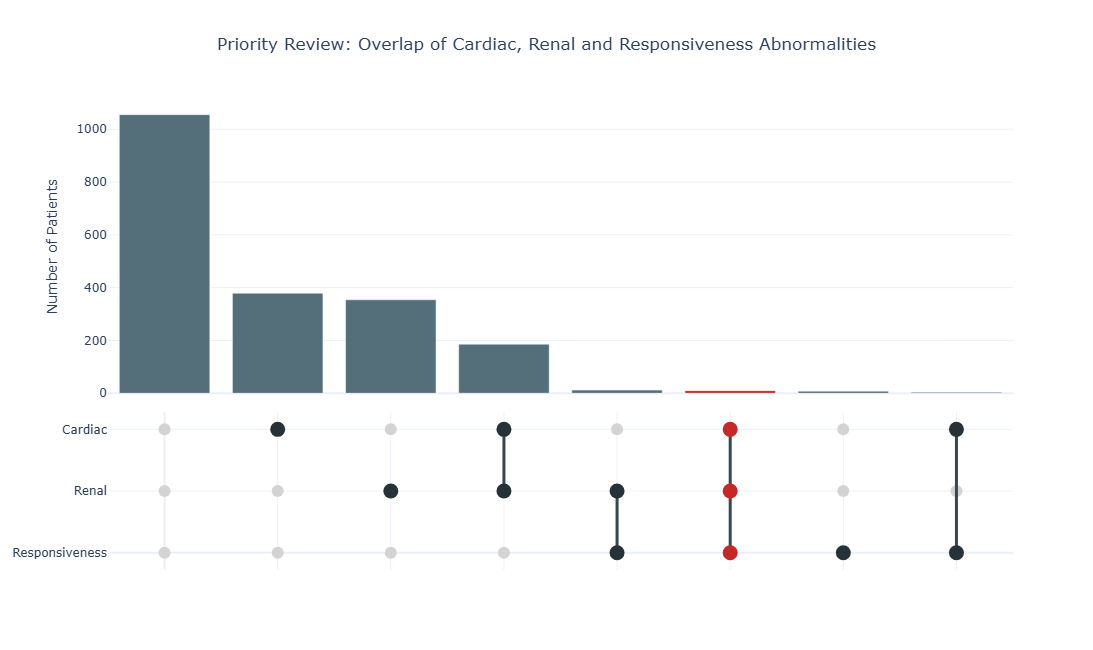

,inpatient_number,brain_natriuretic_peptide,lvef,creatinine_enzymatic_method,glomerular_filtration_rate,consciousness
504,794946,3827.40,20.0,134.3,49.12,Responsive To Sound
870,816910,1873.91,57.0,124.8,50.04,Responsive To Sound
923,798002,5000.00,NaN,172.3,33.17,Responsive To Sound
1035,790433,2971.98,53.0,151.8,37.07,Nonresponsive
1088,830368,1846.38,45.0,154.4,29.99,Responsive To Pain
1120,730841,2670.02,NaN,578.7,5.31,Nonresponsive
1163,827471,5000.00,NaN,237.7,16.47,Responsive To Sound
1258,765343,4152.92,45.0,140.2,39.68,Nonresponsive
1398,828678,4651.31,NaN,636.8,6.98,Responsive To Pain
2006,744870,2614.12,NaN,191.1,32.75,Nonresponsive


Priority-review patients: 10
Percentage of patients: 0.5 %


In [21]:
# -------------------------------------------------------
# Step2. Convert markers to numeric
# -------------------------------------------------------
numeric_cols = [
    "brain_natriuretic_peptide",
    "lvef",
    "creatinine_enzymatic_method",
    "glomerular_filtration_rate"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(
        df[col],
        errors="coerce"
    )

# -------------------------------------------------------
# Step 3. Create exploratory thresholds
# -------------------------------------------------------

bnp_q75 = df["brain_natriuretic_peptide"].quantile(0.75)
lvef_q25 = df["lvef"].quantile(0.25)

creatinine_q75 = df["creatinine_enzymatic_method"].quantile(0.75)
gfr_q25 = df["glomerular_filtration_rate"].quantile(0.25)

print("BNP 75th percentile:", round(bnp_q75, 2))
print("LVEF 25th percentile:", round(lvef_q25, 2))
print("Creatinine 75th percentile:", round(creatinine_q75, 2))
print("GFR 25th percentile:", round(gfr_q25, 2))

# -------------------------------------------------------
# Step 4. Create the three abnormality flags
# -------------------------------------------------------

df["Cardiac"] = (
    (df["brain_natriuretic_peptide"] >= bnp_q75)
    |
    (df["lvef"] <= lvef_q25)
)

df["Renal"] = (
    (df["creatinine_enzymatic_method"] >= creatinine_q75)
    |
    (df["glomerular_filtration_rate"] <= gfr_q25)
)

df["Responsiveness"] = (
    df["consciousness"]
    .astype(str)
    .str.strip()
    .str.lower()
    .ne("clear")
)

print("Cardiac abnormality:", df["Cardiac"].sum())
print("Renal abnormality:", df["Renal"].sum())
print("Abnormal responsiveness:", df["Responsiveness"].sum())

# -------------------------------------------------------
# Step 5.Create priority-review flag
# -------------------------------------------------------
df["Priority_Review"] = (
    df["Cardiac"]
    &
    df["Renal"]
    &
    df["Responsiveness"]
)
print(
    "Patients with all three abnormalities:",
    df["Priority_Review"].sum()
)

# -------------------------------------------------------
# Step 6. Build the intersection data
# -------------------------------------------------------

intersection_data = (
    df.groupby(
        [
            "Cardiac",
            "Renal",
            "Responsiveness"
        ]
    )
    .size()
    .reset_index(
        name="Patients"
    )
)

intersection_data

def combination_name(row):

    conditions = []

    if row["Cardiac"]:
        conditions.append("Cardiac")

    if row["Renal"]:
        conditions.append("Renal")

    if row["Responsiveness"]:
        conditions.append("Responsiveness")

    if len(conditions) == 0:
        return "No Abnormality"

    return " + ".join(conditions)


intersection_data["Combination"] = (
    intersection_data.apply(
        combination_name,
        axis=1
    )
)

intersection_data = (
    intersection_data
    .sort_values(
        "Patients",
        ascending=False
    )
    .reset_index(drop=True)
)

display(intersection_data)

# -------------------------------------------------------
# Step 7. Interactive UpSet Plot
# -------------------------------------------------------

from plotly.subplots import make_subplots
import plotly.graph_objects as go

# Remove combinations with zero patients
plot_df = intersection_data[
    intersection_data["Patients"] > 0
].copy()

plot_df = plot_df.reset_index(drop=True)

x_pos = list(range(len(plot_df)))

fig = make_subplots(
    rows=2,
    cols=1,
    shared_xaxes=True,
    row_heights=[0.65, 0.35],
    vertical_spacing=0.04
)

bar_colors = [
    "#C62828"
    if (
        row["Cardiac"]
        and row["Renal"]
        and row["Responsiveness"]
    )
    else "#546E7A"

    for _, row in plot_df.iterrows()
]

fig.add_trace(
    go.Bar(
        x=x_pos,
        y=plot_df["Patients"],

        marker_color=bar_colors,

        customdata=plot_df[
            ["Combination"]
        ],

        hovertemplate=(
            "<b>%{customdata[0]}</b><br>"
            "Patients: %{y}"
            "<extra></extra>"
        ),

        name="Patients"
    ),
    row=1,
    col=1
)

# -------------------------------------------------------
# Step 8. Add the UpSet dots
# -------------------------------------------------------

conditions = [
    "Cardiac",
    "Renal",
    "Responsiveness"
]

y_positions = {
    "Cardiac": 2,
    "Renal": 1,
    "Responsiveness": 0
}

for i, row in plot_df.iterrows():

    for condition in conditions:

        fig.add_trace(
            go.Scatter(
                x=[i],
                y=[y_positions[condition]],

                mode="markers",

                marker=dict(
                    size=12,
                    color="#D3D3D3"
                ),

                hoverinfo="skip",
                showlegend=False
            ),
            row=2,
            col=1
        )

for i, row in plot_df.iterrows():

    active_y = []

    for condition in conditions:

        if row[condition]:

            active_y.append(
                y_positions[condition]
            )

    # Connecting line
    if len(active_y) > 1:

        fig.add_trace(
            go.Scatter(
                x=[i, i],
                y=[
                    min(active_y),
                    max(active_y)
                ],

                mode="lines",

                line=dict(
                    color="#37474F",
                    width=3
                ),

                hoverinfo="skip",
                showlegend=False
            ),
            row=2,
            col=1
        )

    # Active dots
    for y in active_y:

        priority = (
            row["Cardiac"]
            and row["Renal"]
            and row["Responsiveness"]
        )

        dot_color = (
            "#C62828"
            if priority
            else "#263238"
        )

        fig.add_trace(
            go.Scatter(
                x=[i],
                y=[y],

                mode="markers",

                marker=dict(
                    size=15,
                    color=dot_color
                ),

                hovertemplate=(
                    f"<b>{row['Combination']}</b><br>"
                    f"Patients: {row['Patients']}"
                    "<extra></extra>"
                ),

                showlegend=False
            ),
            row=2,
            col=1
        )

# -------------------------------------------------------
# Step 9. Format the chart
# -------------------------------------------------------

fig.update_yaxes(
    title_text="Number of Patients",
    row=1,
    col=1
)

fig.update_yaxes(
    tickmode="array",
    tickvals=[0, 1, 2],
    ticktext=[
        "Responsiveness",
        "Renal",
        "Cardiac"
    ],
    row=2,
    col=1
)

fig.update_xaxes(
    showticklabels=False,
    row=2,
    col=1
)

fig.update_layout(
    title=dict(
        text=(
            "Priority Review: Overlap of Cardiac, "
            "Renal and Responsiveness Abnormalities"
        ),
        x=0.5
    ),

    template="plotly_white",

    width=950,
    height=650,

    showlegend=False,

    hoverlabel=dict(
        font_size=13
    )
)

fig.show()
priority_patients = df[
    df["Priority_Review"]
].copy()

display(
    priority_patients[
        [
            "inpatient_number",
            "brain_natriuretic_peptide",
            "lvef",
            "creatinine_enzymatic_method",
            "glomerular_filtration_rate",
            "consciousness"
        ]
    ]
)

print(
    "Priority-review patients:",
    len(priority_patients)
)

print(
    "Percentage of patients:",
    round(
        len(priority_patients)
        / len(df) * 100,
        2
    ),
    "%"
)
